## Solving 3D quantum harmonic oscillator

We'll use Numerov algorithm to solve the ODE associated to the problem.

In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
def k(r, l, E):
    """
    Calculate the k(r) function for the Schrödinger equation.
    
    Parameters
    ----------
    r : float
        Position at which k is evaluated.
    l : int
        Angular momentum quantum number.
    E : float
        Energy of the particle.
    
    Returns
    -------
    k if r is different from zero, 1 (sentinel) if r is zero.

    """
    if r != 0:
        return 2 * (E - 0.5 * r**2 - 0.5 * l*(l+1)/(r*r))
    else:
        return 1
    
def isin_classical_region(r, E):
    """
    Check whether the position is within the classical region.

    Parameters
    ----------
    r : float
        The position to be evaluated.
    E : float
        Particle's energy.
    
    Returns
    -------
    True if r is in the classical regione, False otherwise.
    
    """
    return (2*E-0.5*r**2)>0

def numerov_step(psi_prev, psi_curr, k_prev, k_curr, k_next, h):
    """
    Perform a single step of the Numerov method.

    Parameters
    ----------
    psi_prev : float
        The solution at current_position - h.
    psi_curr : float
        The solution at current_position.
    k_prev : float
        The k evaluated at current_position - h.
    k_curr : float
        The k evaluated at current_position.
    k_next : float
        The k evaluated at current_position + h.
    h : float
        The integration step.

    Returns
    -------
    Solution at the next point in the mesh.

    """
    return (2 * (1 - (5 * h**2 * k_curr / 12)) * psi_curr - (1 + (h**2 * k_prev / 12)) * psi_prev) / (1 + (h**2 * k_next / 12))

def _integrate(E, r_min, r_max, h, l, psi_0_outward, psi_1_outward, psi_0_inward, psi_1_inward):
    """
    Perform outward and inward Numerov integration of the radial Schrödinger equation
    and match the solutions in the classically allowed region.

    Parameters
    ----------
    E : float
        Trial energy.
    r_min : float
        Minimum radius for outward integration.
    r_max : float
        Maximum radius for inward integration (must lie in the forbidden region).
    h : float
        Radial grid spacing.
    l : int
        Angular momentum quantum number.
    psi_0_outward, psi_1_outward : float
        Initial values for outward Numerov integration.
    psi_0_inward, psi_1_inward : float
        Initial values for inward Numerov integration (e.g. from WKB).

    Returns
    -------
    coord : ndarray
        Radial grid points.
    psi : ndarray
        Reconstructed wavefunction.
    W : float
        Wronskian mismatch used for eigenvalue search.

    """

    if isin_classical_region(r_max, E):
        # not good, r_max must be after the classical turning point
        print("r_max too small")
        return

    # outward integration (classical region)
    # boundary conditions are known by the problem
    r = r_min
    # create list representing the wave function's values
    psi_outward = []
    psi_outward.append(psi_0_outward)
    psi_outward.append(psi_1_outward)
    # create list representing the wave function's coordinates
    coord_outward = []
    coord_outward.append(r)
    coord_outward.append(r+h)

    # buffer (to keep the matching in the classical region)
    buffer = 10*h

    # outward integration
    while isin_classical_region(r+buffer, E):
        k_prev = k(r, l, E)
        k_curr = k(r+h, l, E)
        k_next = k(r+2*h, l, E)
        temp = numerov_step(psi_0_outward, psi_1_outward, k_prev, k_curr, k_next, h)
        psi_outward.append(temp)
        psi_0_outward = psi_1_outward
        psi_1_outward = temp
        r += h
        coord_outward.append(r+h)

    # inward integration (non-classical region)
    # boundary conditions are known either by the specific problem or by using WKB approximation
    r = r_max 
    # create list representing the wave function's values
    psi_inward= []
    psi_inward.append(psi_0_inward)
    psi_inward.append(psi_1_inward)
    # create list representing the wave function's coordinates
    coord_inward = []
    coord_inward.append(r)
    coord_inward.append(r-h)

    # inward integration
    while not isin_classical_region(r-buffer, E):
        k_prev = k(r, l, E)
        k_curr = k(r-h, l, E)
        k_next = k(r-2*h, l, E)
        temp = numerov_step(psi_0_inward, psi_1_inward, k_prev, k_curr, k_next, -h)
        psi_inward.append(temp)
        if abs(temp) > 1e10:
            # normalize to prevent blow up (scale does not matter in the inward integration)
            psi_0_inward *= 1e-10
            psi_1_inward *= 1e-10
            psi_inward = [x*1e-10 for x in psi_inward]
            temp *= 1e-10
        psi_0_inward = psi_1_inward
        psi_1_inward = temp
        r -= h
        coord_inward.append(r-h)

    # reverse lists for inward integration
    coord_inward = coord_inward[::-1]
    psi_inward = psi_inward[::-1]
    
    
    # at match point index 1 in your local triplet
    temp = psi_outward[::-1]
    uo0, uo1, uo2 = temp[0], temp[1], temp[2]
    ui0, ui1, ui2 = psi_inward[0], psi_inward[1], psi_inward[2]

    if abs(uo1) < 1e-14 or abs(ui1) < 1e-14:
        # match point too close to a node
        return (None, None, np.sign(W)*1e30)

    duo = (uo0 - uo2) / (2*h)     # same stencil, but no /uo1
    dui = (ui2 - ui0) / (2*h)

    W = uo1*dui - ui1*duo

    # numpize and merge solution
    scale = uo1 / ui1
    psi_inward = np.array(psi_inward) * scale
    psi = np.concatenate((psi_outward, psi_inward))
    coord = np.concatenate((coord_outward, coord_inward))

    return (coord, psi, W)


def WKB_inward(r_max, l, h, E):
    """
    Parameters
    ----------
    r_max : float
        Last point of the mesh.
    l : int
        Angular momentum quantum number.

    Returns
    -------
    Returns the WKB approximated starting point for the inward integration.

    """
    return np.sqrt(k(r_max, l, E)/k(r_max-h,l,E))*np.exp(h/2*(k(r_max, l, E)-k(r_max-h,l,E)))

    
def bisection(err_prev, err_curr, E_prev, E_curr, tol, r_min, r_max, h, l, psi_0_outward, psi_1_outward, psi_0_inward, psi_1_inward):
    """
    Perform the bisection method in order to find the zero of the Wronskian mismatch between two energies that make its sign change.

    Parameters
    ----------
    err_prev : float
        Previous Wronskian mismatch.
    err_curr : float
        Current Wronskian mismatch.
    E_prev : float
        Previous energy.
    E_curr : float
        Current energy.
    tol : float
        Numerical tolerance.
    r_min : float
        Minimum radius for outward integration.
    r_max : float
        Maximum radius for inward integration (must lie in the forbidden region).
    h : float
        Radial grid spacing.
    l : int
        Angular momentum quantum number.
    psi_0_outward, psi_1_outward : float
        Initial values for outward Numerov integration.
    psi_0_inward, psi_1_inward : float
        Initial values for inward Numerov integration (e.g. from WKB).

    Returns
    -------
    coord : ndarray
        Radial grid points.
    psi : ndarray
        Reconstructed wavefunction.
    energy : float
        Estimated zero of Wronskian mismatch (energy eigenvalue)
    """
    if np.sign(err_prev) == np.sign(err_curr):
        print('Invalid starting points')
        pass

    while(abs(E_prev-E_curr) > tol):
        E_med = (E_prev + E_curr)/2
        coord, psi, new_error = _integrate(E_med, r_min, r_max, h, l, psi_0_outward, psi_1_outward, psi_0_inward, psi_1_inward)
        
        if np.sign(err_prev) == np.sign(new_error):
            E_prev = E_med
        else:
            E_curr = E_med
            
    energy = (E_prev + E_curr)/2
    return (coord, psi, energy)

def integrate(E, l, r_min, r_max, h, psi_0_outward, psi_1_outward, psi_0_inward, psi_1_inward):
    """
    Perform the integration using Numerov algorithm for the specified angular momentum list and energy range.
    
    Parameters
    ----------
    E : iterable
        Energy list in which the integration is performed.
    l : iterable
        Angular momentum list in which the integration is performed.
    tol : float
        Numerical tolerance.
    r_min : float
        Minimum radius for outward integration.
    r_max : float
        Maximum radius for inward integration (must lie in the forbidden region).
    h : float
        Radial grid spacing.
    psi_0_outward, psi_1_outward : float
        Initial values for outward Numerov integration.
    psi_0_inward, psi_1_inward : float
        Initial values for inward Numerov integration (e.g. from WKB).

    Returns
    -------

    """
    err_prev = None
    err_curr = 0
    E_prev = None

    for _l in l:
        for _E in E:
            coord, psi, error = _integrate(_E, r_min, r_max, h, _l, psi_0_outward, psi_1_outward, psi_0_inward, psi_1_inward)
            err_curr = error
            if err_prev is not None and E_prev is not None and np.sign(err_curr) != np.sign(err_prev):
                coord, psi, good_energy = bisection(err_prev, err_curr, E_prev, E, 1e-6, r_min, r_max, h, l, 0, np.pow(h, l+1), 1, psi_1_inward)
                print("Found energy at : E = {:.3f} l = {} h = {}".format(good_energy, l, h))
                plt.plot(coord, psi, label = "E = {}, l = {}".format(good_energy, l))
                plt.legend()
                plt.show()
            E_prev = E
            err_prev = err_curr

        err_prev = None
        E_prev = None


Energy = 1.500 l = 0 h = 0.0001


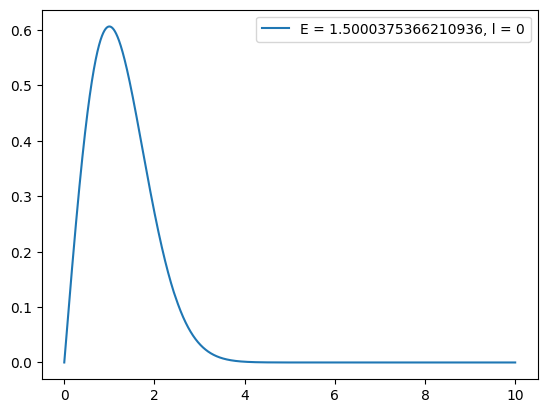

KeyboardInterrupt: 

In [ ]:
h = .0001
r_min = 0
r_max = 10

err_prev = None
err_curr = 0

E_prev = None

for l in [0]:
    for E in np.arange(1.4, 10, 0.01):
        psi_1_inward = WKB_inward(r_max, l, h, E)
        coord, psi, error = _integrate(E, r_min, r_max, h, l, 0, np.pow(h, l+1), 1, psi_1_inward)
        err_curr = error
        #print("E = {} err_prev = {} err_curr = {}".format(E, err_prev, err_curr))
        if err_prev is not None and E_prev is not None and np.sign(err_curr) != np.sign(err_prev):
            coord, psi, good_energy = bisection(err_prev, err_curr, E_prev, E, 1e-6, r_min, r_max, h, l, 0, np.pow(h, l+1), 1, psi_1_inward)
            print("Energy = {:.3f} l = {} h = {}".format(good_energy, l, h))
            plt.plot(coord, psi, label = "E = {}, l = {}".format(good_energy, l))
            plt.legend()
            plt.show()
        E_prev = E
        err_prev = err_curr
    
    err_prev = None
    E_prev = None